# Library import & Data load

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\Aleeza\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [2]:
df.EmployeeNumber.value_counts()

EmployeeNumber
1       1
1391    1
1389    1
1387    1
1383    1
       ..
659     1
657     1
656     1
655     1
2068    1
Name: count, Length: 1470, dtype: int64

# prediction

In [3]:
#prediction
df['Attrition'] = df['Attrition'].map({'Yes' :1,'No' : 0})
df ['Age'] = df['Age'].map({'Yes' :1,'No' : 0})
df['Department'] = df['Department'].map({'Yes' :1,'No' : 0})

In [4]:

df_clean = pd.get_dummies(df, drop_first=True)

In [5]:
!pip install xgboost


# Import Libraries

In [6]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
df.drop(['DistanceFromHome','EmployeeCount','StandardHours'],axis = 1)

,Age,Attrition,BusinessTravel,DailyRate,Department,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,NaN,1,Travel_Rarely,1102,NaN,2,Life Sciences,1,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,NaN,0,Travel_Frequently,279,NaN,1,Life Sciences,2,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,NaN,1,Travel_Rarely,1373,NaN,2,Other,4,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,NaN,0,Travel_Frequently,1392,NaN,4,Life Sciences,5,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,NaN,0,Travel_Rarely,591,NaN,1,Medical,7,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,NaN,0,Travel_Frequently,884,NaN,2,Medical,2061,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,NaN,0,Travel_Rarely,613,NaN,1,Medical,2062,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,NaN,0,Travel_Rarely,155,NaN,3,Life Sciences,2064,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,NaN,0,Travel_Frequently,1023,NaN,3,Medical,2065,4,Male,...,3,4,0,17,3,2,9,6,0,8


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

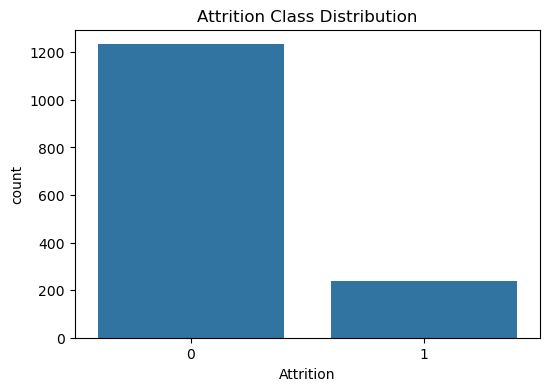

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition')
plt.title('Attrition Class Distribution')
plt.show()

In [12]:
from sklearn.ensemble import RandomForestClassifier
from  sklearn.model_selection import train_test_split

In [13]:
X = df_clean.drop(['Attrition'], axis=1)
Y = df_clean['Attrition']

# Model Train

In [15]:

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=45)


print(X_train.shape, X_test.shape)

(1176, 46) (294, 46)


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (1176, 46)
Testing data shape: (294, 46)


C:\Users\Aleeza\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\Aleeza\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\Aleeza\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [17]:
# 1. Saare text columns ko encode karein
df_clean = pd.get_dummies(df, drop_first=True)

# 2. Check karein ke kis column mein NaNs hain (optional check)
# print(df_clean.isna().sum())

# 3. Saare NaNs/Missing values wali rows ko hamesha ke liye drop (remove) kar dein
df_clean = df_clean.dropna()

In [18]:
# Yeh line aapke features (X) aur target (Y) ke combination se saari NaN rows nikaal degi
df = df.dropna()

In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=45),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=45),
    "Random Forest": RandomForestClassifier(n_jobs=-1, class_weight='balanced', random_state=45),
    "XGBoost": XGBClassifier(random_state=45)
}

#  Evaluation Metrics 

In [25]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Step 1: Pehle Missing Values (NaN) ko handle karein
imputer = SimpleImputer(strategy='mean')
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

# Step 2: Results store karne ke liye dictionary
results_dict = {}

print("--- Model Training Results ---")
# Step 3: Training Loop
for name, model in models.items():
    # Model ko train karna
    model.fit(X_train_scaled, Y_train)
    predictions = model.predict(X_test_scaled)
    
    # Metrics calculate karna
    acc = accuracy_score(Y_test, predictions)
    prec = precision_score(Y_test, predictions)
    rec = recall_score(Y_test, predictions)
    f1 = f1_score(Y_test, predictions)
    
    # Results save karna
    results_dict[name] = [acc, prec, rec, f1]
    
    # Har model ke saare metrics professional tariqe se print karna
    print(f"\n⭐ Model: {name}")
    print(f"  - Accuracy : {acc * 100:.2f}%")
    print(f"  - Precision: {prec * 100:.2f}%")
    print(f"  - Recall   : {rec * 100:.2f}%")
    print(f"  - F1-Score : {f1 * 100:.2f}%")
    print("-" * 30)

--- Model Training Results ---

⭐ Model: Logistic Regression
  - Accuracy : 73.81%
  - Precision: 41.07%
  - Recall   : 80.70%
  - F1-Score : 54.44%
------------------------------

⭐ Model: Decision Tree
  - Accuracy : 77.89%
  - Precision: 41.67%
  - Recall   : 35.09%
  - F1-Score : 38.10%
------------------------------

⭐ Model: Random Forest
  - Accuracy : 81.63%
  - Precision: 100.00%
  - Recall   : 5.26%
  - F1-Score : 10.00%
------------------------------

⭐ Model: XGBoost
  - Accuracy : 84.69%
  - Precision: 73.08%
  - Recall   : 33.33%
  - F1-Score : 45.78%
------------------------------


In [21]:
model=RandomForestClassifier(n_jobs = -1,random_state = 45)

In [22]:
model.fit(X_train,Y_train)
accuracy = model.score(X_test, Y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 82.65%


In [23]:
# Sahi attributes aur commas ke sath feature importance nikalne ka tareeqa
sorted_importance = dict(sorted(zip(model.feature_names_in_, model.feature_importances_), key=lambda x: x[1], reverse=True))

# Top 5 important features dekhne ke liye:
for feature, importance in list(sorted_importance.items())[:5]:
    print(f"{feature}: {importance:.4f}")

MonthlyIncome: 0.0764
TotalWorkingYears: 0.0567
EmployeeNumber: 0.0522
MonthlyRate: 0.0500
DailyRate: 0.0493


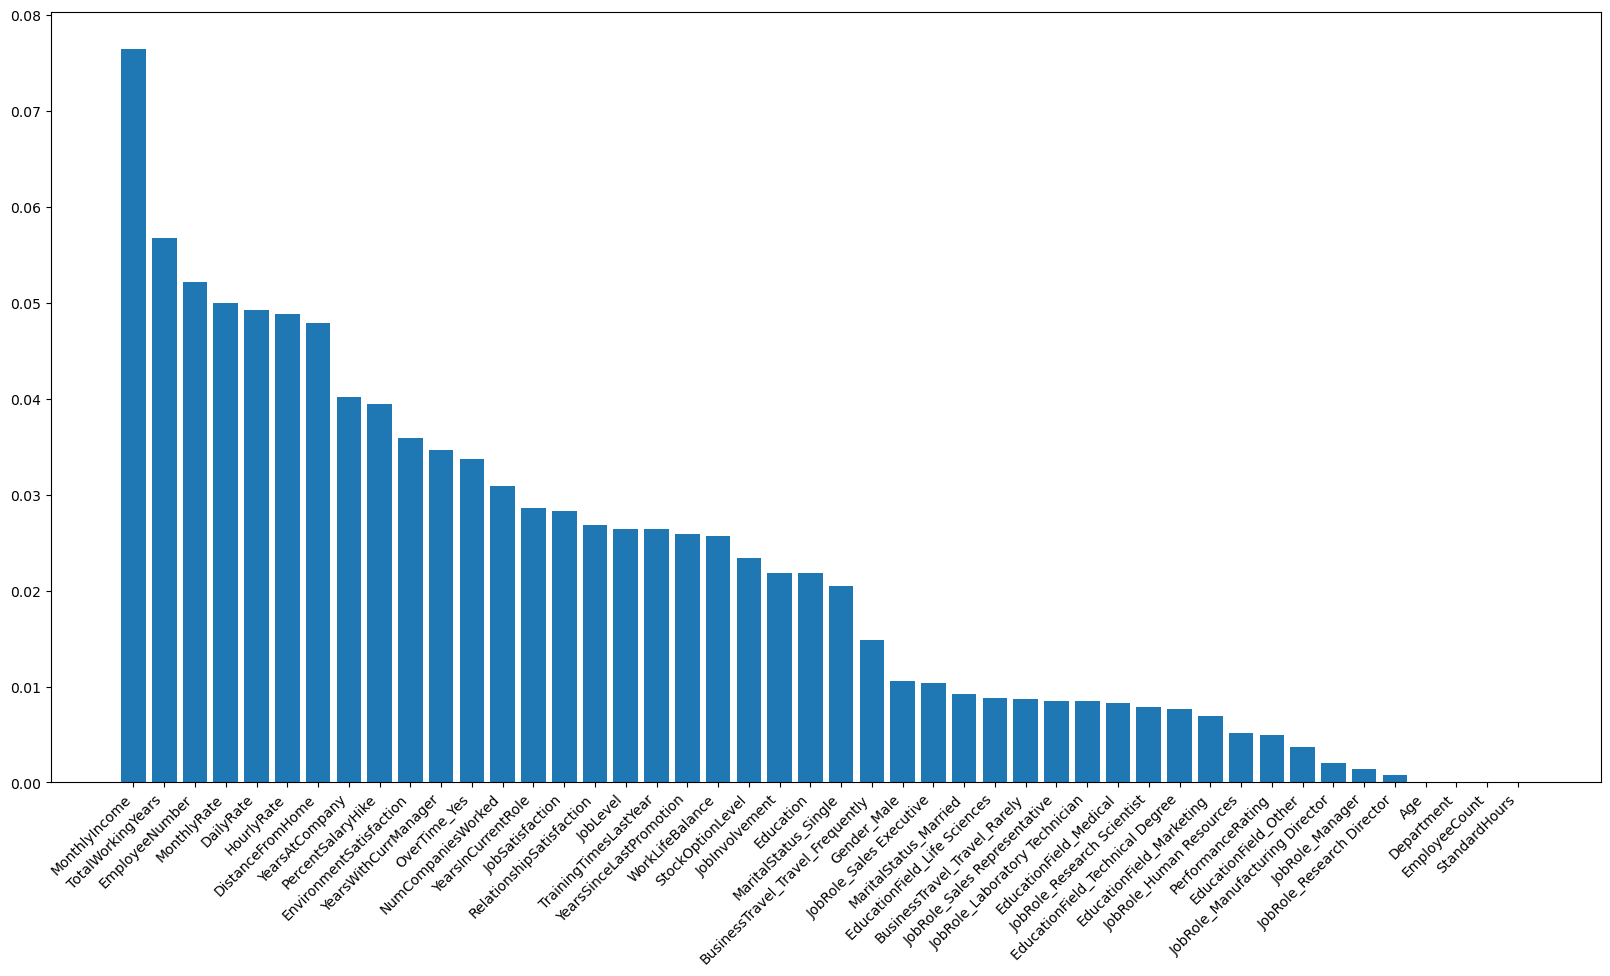

In [24]:
import matplotlib.pyplot as plt

# Figure size
plt.figure(figsize=(20, 10))

# call the dictionary key and values
plt.bar(sorted_importance.keys(), sorted_importance.values())


plt.xticks(rotation=45, ha='right')

# Chart display
plt.show()